In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../Datasets/seattle-weather.csv')
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
print(df.isnull().sum())
print(df.duplicated().sum())

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64
0


<Axes: xlabel='wind', ylabel='Count'>

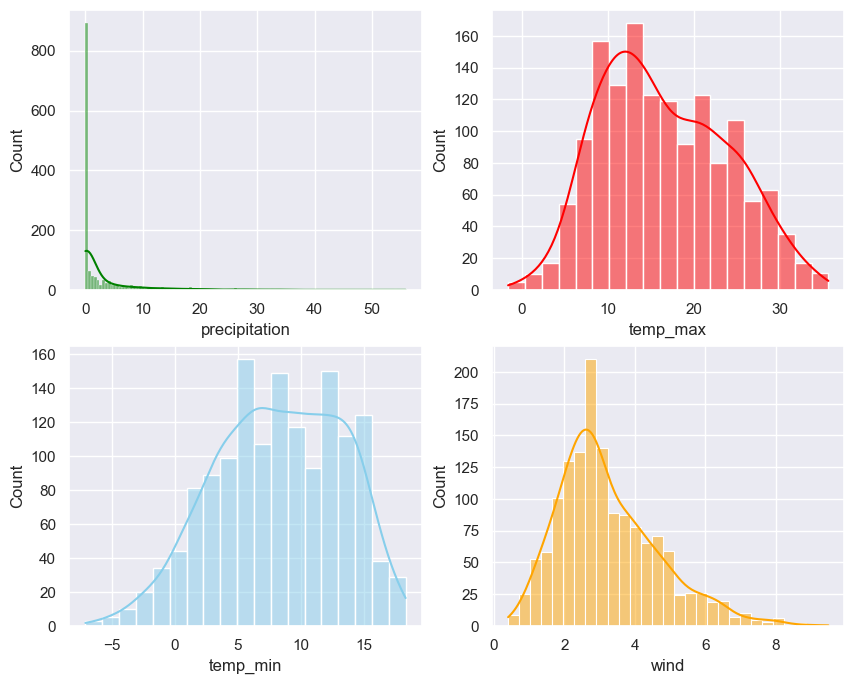

In [4]:
sns.set(style="darkgrid")
fig,axs=plt.subplots(2,2,figsize=(10,8))
sns.histplot(data=df,x="precipitation",kde=True,ax=axs[0,0],color='green')
sns.histplot(data=df,x="temp_max",kde=True,ax=axs[0,1],color='red')
sns.histplot(data=df,x="temp_min",kde=True,ax=axs[1,0],color='skyblue')
sns.histplot(data=df,x="wind",kde=True,ax=axs[1,1],color='orange')

In [74]:
# [date, precipitation, temp_max, temp_min, wind, weather]
training_set = df.iloc[:,1:5].values
training_set
scaler = MinMaxScaler(feature_range=(0,1))
training_set = scaler.fit_transform(training_set)
training_set

array([[0.        , 0.38709677, 0.47637795, 0.47252747],
       [0.19499106, 0.32795699, 0.38976378, 0.45054945],
       [0.01431127, 0.35752688, 0.56299213, 0.20879121],
       ...,
       [0.        , 0.23655914, 0.30314961, 0.24175824],
       [0.        , 0.19354839, 0.24015748, 0.32967033],
       [0.        , 0.19354839, 0.19685039, 0.34065934]])

In [79]:
def df_to_XY(data, window_size=60):
    X = []
    y = []
    
    for i in range(window_size, len(data) - 1):
        # X: Los 60 días pasados con las 4 características
        X.append(data[i-window_size:i, 0:4]) 
        
        # y: La característica deseada (temp_max en índice 1) 
        # para el día actual [i] y el día siguiente [i+1]
        y.append(data[i : i+2, 1]) 
        
    return np.array(X), np.array(y)

In [80]:
timesteps = 60
X, y = df_to_XY(training_set, timesteps)
X_train, y_train = X[:800], y[:800]
X_val, y_val = X[800:1000], y[800:1000]
X_test, y_test = X[1000:], y[1000:]
print(X_train.shape) 
    
print("Forma final de X_train:", X_train.shape) # (800, 60, 4)
print("Forma final de y_train:", y_train.shape) # (800, 2)

(800, 60, 4)
Forma final de X_train: (800, 60, 4)
Forma final de y_train: (800, 2)


In [ ]:
# Reshaping(To add new dimensions)
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
X_val = np.reshape(X_val,(X_val.shape[0],X_val.shape[1],1))
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))
print(X_train.shape,X_val.shape, X_test.shape)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, SimpleRNN, BatchNormalization

model = Sequential()
model.add(Input(shape=(timesteps, 4))) 
model.add(SimpleRNN(60, activation='relu', return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(SimpleRNN(60, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(60))
model.add(BatchNormalization())
model.add(Dense(30))
model.add(Dense(2)) # Las 2 salidas

model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_18 (SimpleRNN)       │ (None, 60, 60)         │         3,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 60, 60)         │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 60, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_19 (SimpleRNN)       │ (None, 60)             │         7,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 60)             │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 2)              │            62 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,192 (67.16 KB)

 Trainable params: 16,952 (66.22 KB)

 Non-trainable params: 240 (960.00 B)

In [82]:
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 1.2196 - mae: 0.8350 - val_loss: 0.0855 - val_mae: 0.2509
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1470 - mae: 0.2917 - val_loss: 0.0352 - val_mae: 0.1622
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0608 - mae: 0.1917 - val_loss: 0.0401 - val_mae: 0.1658
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0424 - mae: 0.1547 - val_loss: 0.0284 - val_mae: 0.1416
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0361 - mae: 0.1470 - val_loss: 0.0197 - val_mae: 0.1160
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0425 - mae: 0.1555 - val_loss: 0.0171 - val_mae: 0.1053
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0311 - mae: 0.1378 - val_loss: 0.0275 - val_mae: 0.1384
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0288 - mae: 0.1311 - val_loss: 0.0161 - val_mae: 0.1029
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - lo

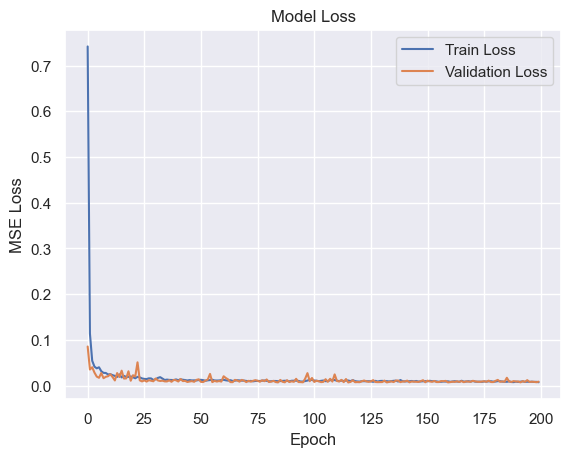

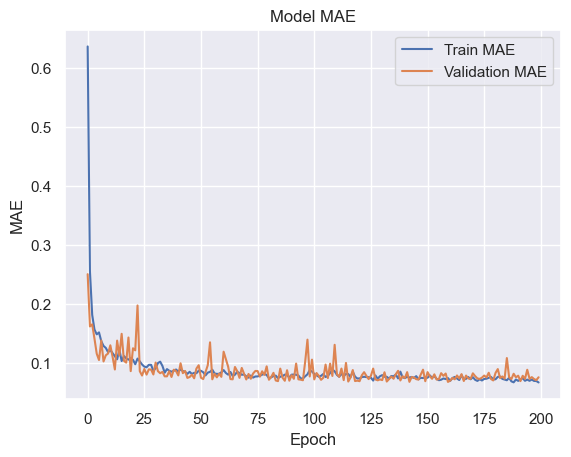

In [83]:
# --- Loss ---
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- MAE ---
plt.figure()
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model MAE')
plt.legend()
plt.grid(True)
plt.show()

In [84]:
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test.reshape(X_test.shape[0],1))
# y_test = scaler.inverse_transform(y_test)
rmse = np.sqrt(((y_test - y_pred)**2).mean())
rmse

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


ValueError: operands could not be broadcast together with shapes (400,2) (4,) (400,2) 

In [85]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score, explained_variance_score

def report(y_test,y_pred):
    print("RMSE: ", math.sqrt(mean_squared_error(y_test,y_pred)))
    print("MSE: ", mean_squared_error(y_test,y_pred))
    print("MAE: ", mean_absolute_error(y_test,y_pred))
    print("Explained variance regression score:",
          explained_variance_score(y_test, y_pred))
    print('R2: ', r2_score(y_test, y_pred))
report(y_test,y_pred)


actual = df[['temp_max']]
pred   = df[['temp_max']].iloc[training_set.shape[0] - y_pred.shape[0]:, :]

pred[['Predict']] = y_pred
plt.figure(figsize=(16, 8))
plt.plot(actual, label='Actual')
plt.plot(pred[['Predict']], label='Predict')
plt.legend()
ax = plt.gca()
ax.set_xlim([1000, 1451])
plt.show()

RMSE:  0.09077999883553774
MSE:  0.008241008188580234
MAE:  0.07243103327930608
Explained variance regression score: 0.8059856114842372
R2:  0.7904602595966581


ValueError: Columns must be same length as key